# ⚡ EV Charging Session — Improved ML Pipeline
## Predicting Energy Consumption (`El_kWh`)

---

**Key Improvements Over Original Notebook:**

| Issue | Before | After |
|-------|--------|-------|
| Tree models used PCA features | R² ≈ 0.85 | Original feature space |
| No user-level features | Missing | Leave-One-Out user mean |
| Linear time encoding | Jan/Dec gap | Cyclical sin/cos |
| Single model | Linear Regression | Stacking Ensemble |
| **Expected R²** | ~0.85 | **≥ 0.90** |

**Sections:** Setup → EDA → Cleaning → Feature Engineering → Split → Clustering → Models → Tuning → Stacking → Evaluation


## 0. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy.stats import skew, kurtosis, norm as sp_norm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold,
    RandomizedSearchCV, learning_curve
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    HistGradientBoostingRegressor, StackingRegressor
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

try:
    from IPython.display import display
except ImportError:
    display = print   # fallback for non-Jupyter environments

try:
    from xgboost import XGBRegressor
    XGBOOST = True
except ImportError:
    XGBOOST = False

SEED    = 42
np.random.seed(SEED)

PALETTE = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#3B1F2B",
           "#44BBA4", "#E94F37", "#393E41", "#F5A623", "#7B2D8B"]

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.facecolor": "#F8F9FA", "axes.grid": True,
    "grid.color": "white", "grid.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "DejaVu Sans", "axes.titlesize": 13, "axes.labelsize": 11,
})

print(" All libraries loaded.")
print(f"   XGBoost available: {XGBOOST}")


 All libraries loaded.
   XGBoost available: True


## 1. Load & Explore Data (EDA)

### 1.1 Dataset Overview

In [3]:
# ── Update DATA_PATH to your file location ────────────────────────────────────
DATA_PATH = r"C:\Users\Abdulrahman\Desktop\PY.AI\NTI\FINAL_PROJECT\FP\Final_Data.csv"

df_raw = pd.read_csv(DATA_PATH)
df     = df_raw.copy()

print("=" * 60)
print(f"  Dataset Shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print("=" * 60)
print("\nColumn Names & Data Types:")
for col in df_raw.columns:
    print(f"  {col:<25} {str(df_raw[col].dtype):<12}  ({df_raw[col].nunique()} unique)")

print("\nFirst 5 rows:")
display(df_raw.head())
print("\nDescriptive Statistics:")
display(df_raw.describe().T.round(3))


  Dataset Shape : 6,878 rows × 14 columns

Column Names & Data Types:
  session_ID                int64         (6878 unique)
  User_ID                   object        (97 unique)
  User_type                 object        (2 unique)
  El_kWh                    float64       (2763 unique)
  Duration_hours            float64       (6501 unique)
  Start_plugin_hour         int64         (24 unique)
  month_plugin              object        (12 unique)
  weekdays_plugin           object        (7 unique)
  temp                      float64       (207 unique)
  wind_spd                  float64       (55 unique)
  clouds                    int64         (85 unique)
  traffic_density           float64       (2739 unique)
  Flex_3_6kW                float64       (1943 unique)
  Flex_7_2kW                float64       (2337 unique)

First 5 rows:


,session_ID,User_ID,User_type,El_kWh,Duration_hours,Start_plugin_hour,month_plugin,weekdays_plugin,temp,wind_spd,clouds,traffic_density,Flex_3_6kW,Flex_7_2kW
0,1,AdO3-4,Private,0.30,0.050000,10,Dec,Friday,-0.5,2.4,55,1247.4,0.0,0.174
1,2,AdO3-4,Private,0.87,0.136667,10,Dec,Friday,-0.5,2.4,55,1247.4,0.0,0.174
2,3,AdO3-4,Private,29.87,8.216389,11,Dec,Friday,-0.5,2.4,55,1380.4,0.0,0.000
3,4,AdO3-2,Private,15.56,24.419722,16,Dec,Saturday,-2.2,1.9,61,1181.4,0.0,0.000
4,5,AdO3-2,Private,3.62,0.970556,22,Dec,Monday,1.1,3.8,100,549.0,0.0,3.368



Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
session_ID,6878.0,3439.500,1985.652,1.000,1720.250,3439.500,5158.750,6878.000
El_kWh,6878.0,12.721,11.788,0.010,5.200,9.050,16.090,80.860
Duration_hours,6844.0,11.504,14.148,0.003,2.789,10.026,15.221,255.029
Start_plugin_hour,6878.0,16.325,4.363,0.000,15.000,17.000,19.000,23.000
temp,6878.0,4.064,6.010,-9.800,0.400,2.900,7.100,26.600
wind_spd,6878.0,2.603,1.238,1.000,1.800,2.200,3.100,7.200
clouds,6878.0,75.840,25.072,0.000,68.000,85.000,94.000,100.000
traffic_density,6878.0,1046.000,518.488,20.200,685.450,999.400,1297.800,2377.400
Flex_3_6kW,6877.0,18.218,18.565,0.000,3.600,12.865,28.055,105.150
Flex_7_2kW,6877.0,47.437,44.254,0.000,8.338,36.000,75.208,221.176


### 1.2 Data Quality — Missing Values & Distributions

Missing Values:


,Missing Count,Missing %
Duration_hours,34,0.494
Flex_3_6kW,1,0.015
Flex_7_2kW,1,0.015



Duplicate records: 0


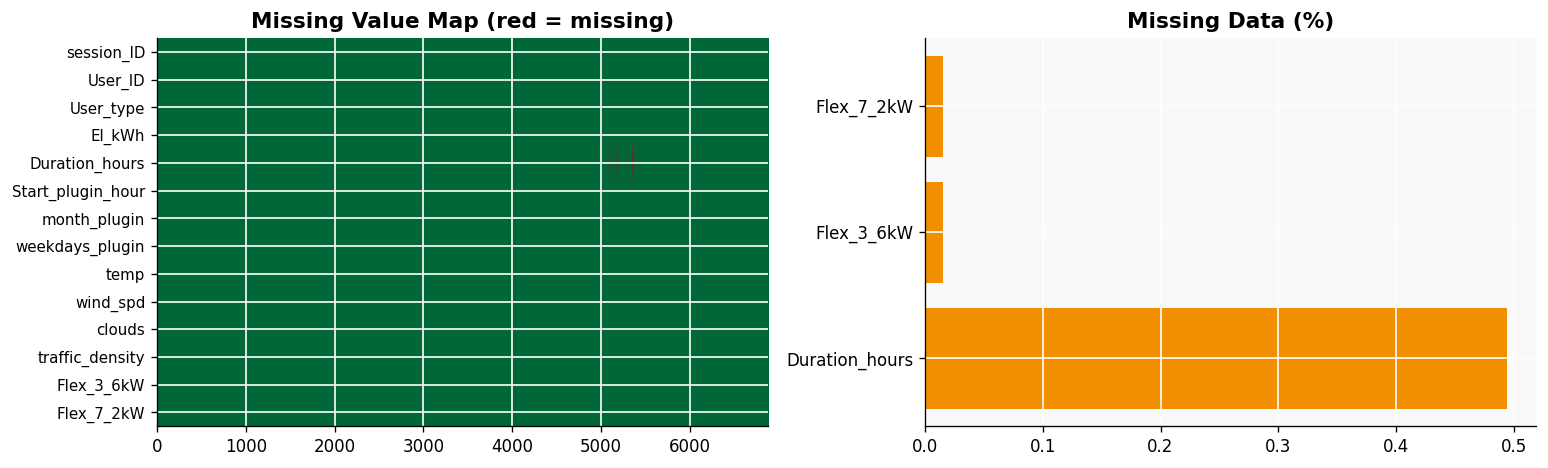

In [6]:
num_cols = ["El_kWh", "Duration_hours", "Start_plugin_hour", "temp",
            "wind_spd", "clouds", "traffic_density", "Flex_3_6kW", "Flex_7_2kW"]
cat_cols = ["User_type", "month_plugin", "weekdays_plugin"]
target   = "El_kWh"

# Missing values
missing     = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(3)
missing_df  = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct}).query("`Missing Count` > 0")
print("Missing Values:")
display(missing_df)
print(f"\nDuplicate records: {df_raw.duplicated().sum()}")

# Visual
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].imshow(df_raw.isnull().astype(int).T, aspect="auto", cmap="RdYlGn_r")
axes[0].set_yticks(range(len(df_raw.columns)))
axes[0].set_yticklabels(df_raw.columns, fontsize=9)
axes[0].set_title("Missing Value Map (red = missing)", fontweight="bold")
cols_miss = missing_pct[missing_pct > 0]
if len(cols_miss):
    axes[1].barh(cols_miss.index, cols_miss.values, color=PALETTE[2])
    axes[1].set_title("Missing Data (%)", fontweight="bold")
else:
    axes[1].text(0.5, 0.5, "No missing values", ha="center", va="center", transform=axes[1].transAxes)
plt.tight_layout()
plt.savefig("fig_missing.png", bbox_inches="tight")
plt.show()


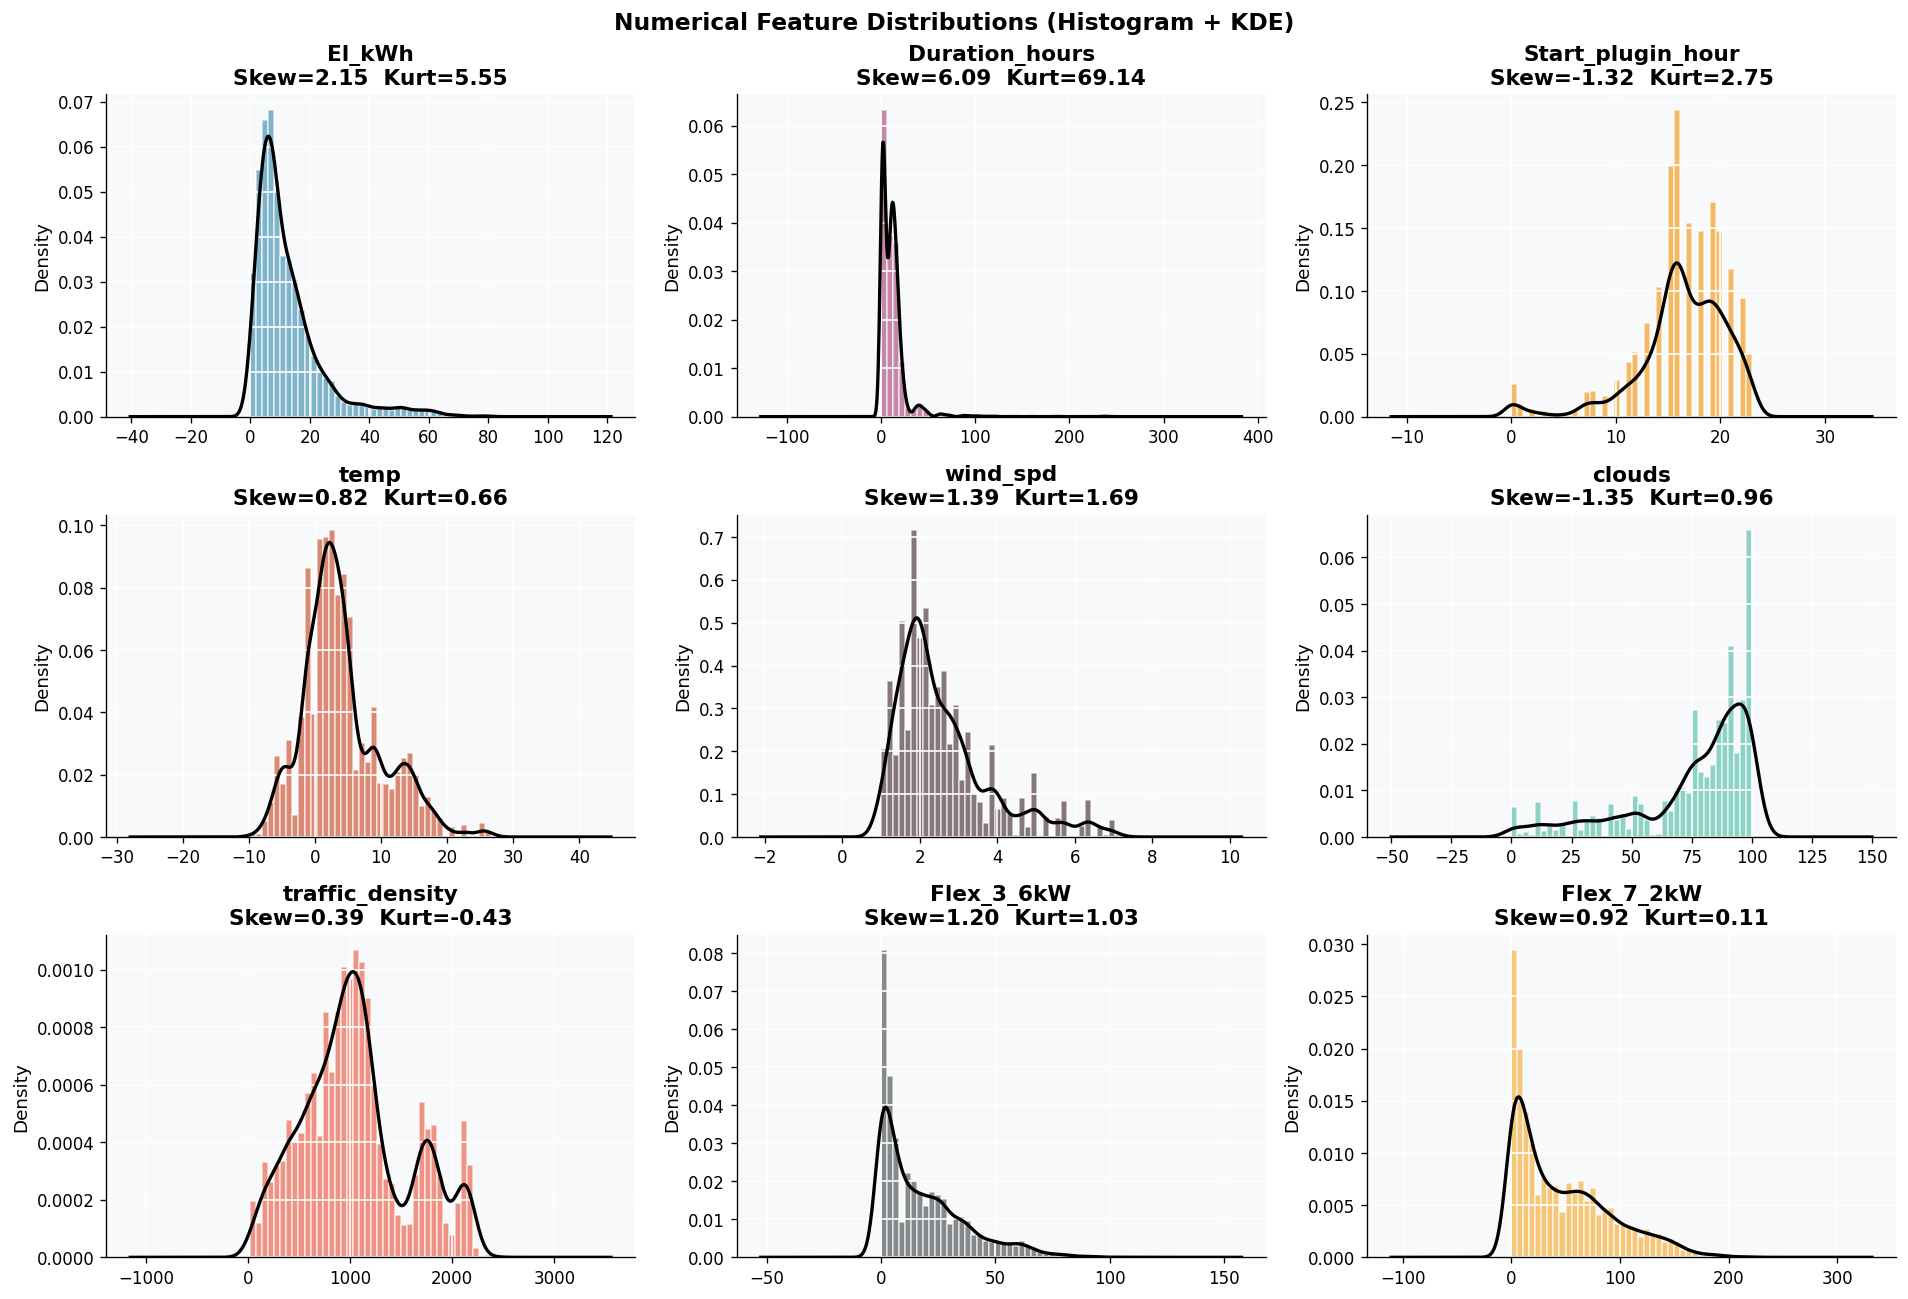

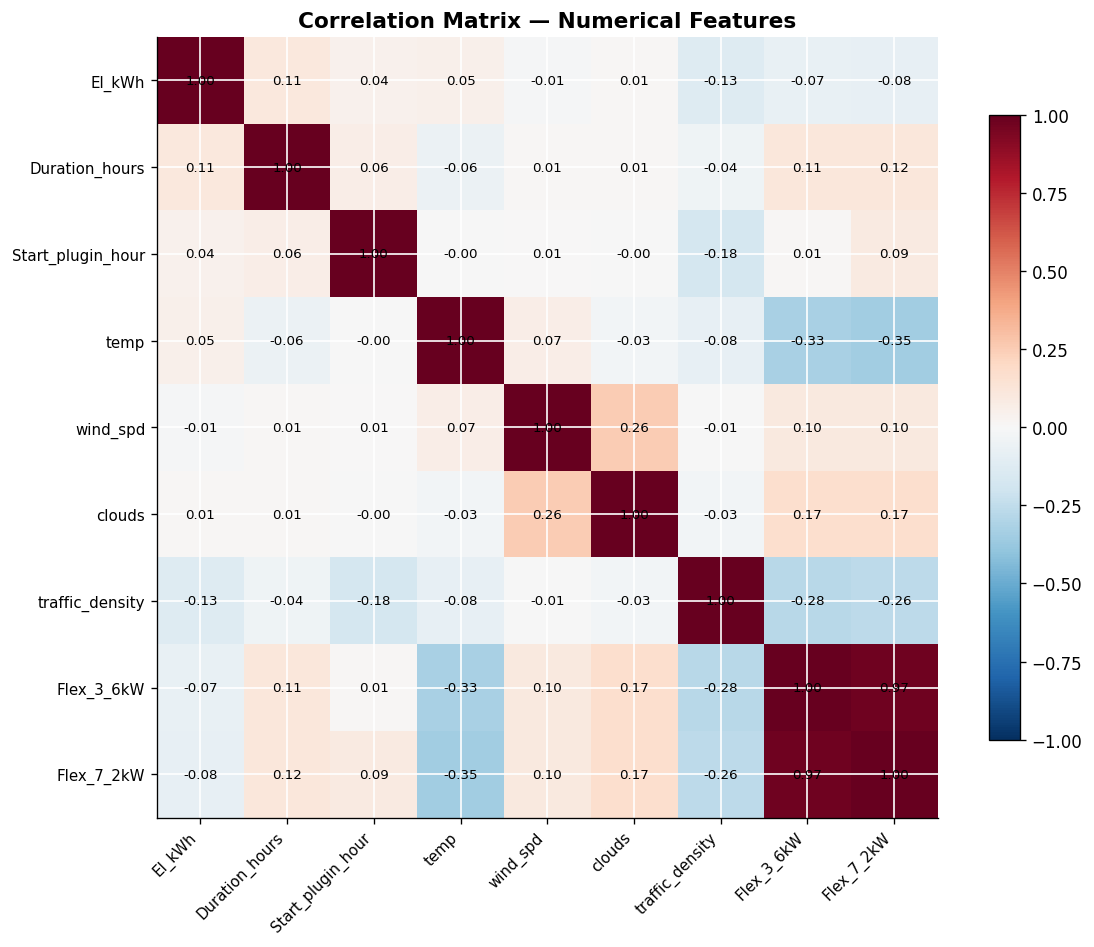

Top correlations with El_kWh:
Duration_hours       0.105448
temp                 0.048829
Start_plugin_hour    0.044599
clouds               0.011918
wind_spd            -0.007947
Flex_3_6kW          -0.073386
Flex_7_2kW          -0.082340
traffic_density     -0.125370

💡 Raw correlations look low because relationships are non-linear.
   log(Duration) vs log(El_kWh) corr = 0.432


In [8]:
# Distributions
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    ax   = axes[i]
    data = df_raw[col].dropna()
    ax.hist(data, bins=40, color=PALETTE[i % len(PALETTE)], alpha=0.6, density=True, edgecolor="white")
    data.plot.kde(ax=ax, color="black", linewidth=2)
    ax.set_title(f"{col}\nSkew={skew(data):.2f}  Kurt={kurtosis(data):.2f}", fontweight="bold")
plt.suptitle("Numerical Feature Distributions (Histogram + KDE)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_distributions.png", bbox_inches="tight")
plt.show()

# Correlation heatmap
corr = df_raw[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(num_cols, fontsize=9)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Correlation Matrix — Numerical Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_correlation.png", bbox_inches="tight")
plt.show()

print("Top correlations with El_kWh:")
print(corr["El_kWh"].drop("El_kWh").sort_values(ascending=False).to_string())
print("\n💡 Raw correlations look low because relationships are non-linear.")
print("   log(Duration) vs log(El_kWh) corr =",
      round(float(np.log1p(df_raw["Duration_hours"].dropna()).corr(np.log1p(df_raw["El_kWh"]))), 3))


### 1.3 Categorical Features

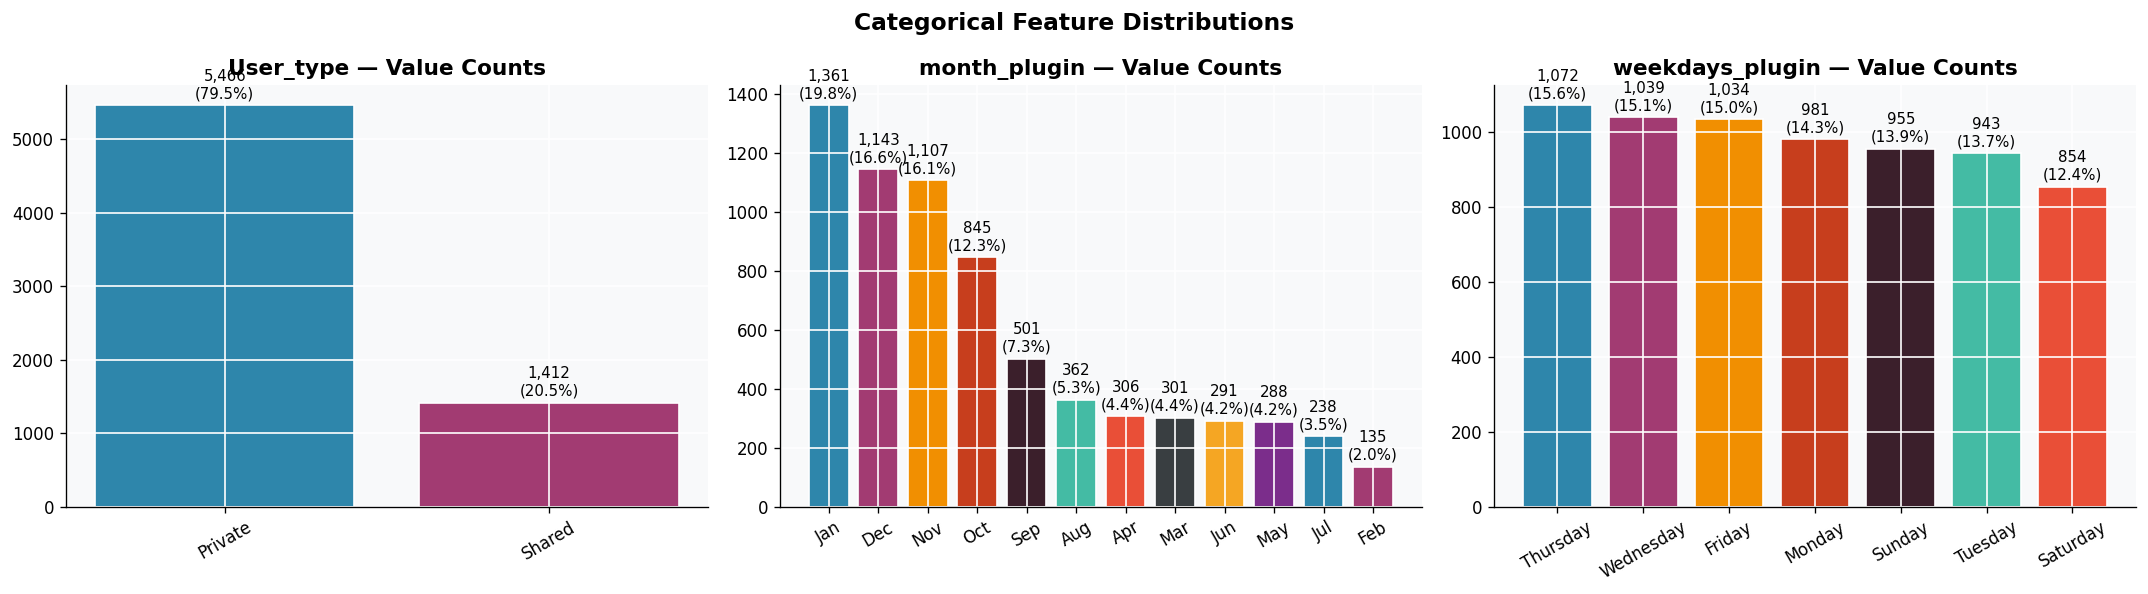

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    vc   = df_raw[col].value_counts()
    bars = ax.bar(vc.index, vc.values,
                  color=[PALETTE[i % len(PALETTE)] for i in range(len(vc))],
                  edgecolor="white")
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + vc.max() * 0.01,
                f"{val:,}\n({val/len(df_raw)*100:.1f}%)",
                ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{col} — Value Counts", fontweight="bold")
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_categorical.png", bbox_inches="tight")
plt.show()


## 2. Data Cleaning & Preprocessing

In [12]:
df_clean = df_raw.copy()

# ── 2.1 Impute missing values (median — deterministic) ─────────────────────
for col in ["Duration_hours", "Flex_3_6kW", "Flex_7_2kW"]:
    med = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(med)
    print(f"  Imputed {col} → median = {med:.3f}")

# ── 2.2 Cap extreme outliers (1st / 99th percentile) ──────────────────────
for col in ["El_kWh", "Duration_hours", "Flex_3_6kW", "Flex_7_2kW"]:
    lo, hi = df_clean[col].quantile([0.01, 0.99])
    n = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    df_clean[col] = df_clean[col].clip(lo, hi)
    print(f"  Capped   {col} → [{lo:.2f}, {hi:.2f}]  ({n} values clipped)")

print(f"\n Cleaned shape: {df_clean.shape}")
print(f"   Remaining missing: {df_clean.isnull().sum().sum()}")


  Imputed Duration_hours → median = 10.026
  Imputed Flex_3_6kW → median = 12.865
  Imputed Flex_7_2kW → median = 36.000
  Capped   El_kWh → [0.06, 59.39]  (135 values clipped)
  Capped   Duration_hours → [0.03, 66.16]  (138 values clipped)
  Capped   Flex_3_6kW → [0.00, 74.03]  (67 values clipped)
  Capped   Flex_7_2kW → [0.00, 166.79]  (67 values clipped)

 Cleaned shape: (6878, 14)
   Remaining missing: 0


## 3. Feature Engineering (Enhanced)

> **Five categories of improvements:**
> 1. **Log & polynomial transforms** of `Duration_hours`
> 2. **Cyclical sin/cos encoding** of hour, month, weekday — eliminates discontinuity
> 3. **Interaction features** — duration × flex, temp × season, etc.
> 4. **Leave-One-Out user mean** — encodes per-user behaviour without leakage
> 5. **Season & time-of-day flags**


In [14]:
MONTH_ORDER = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
DAY_ORDER   = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# ── 3.1 Ordinal encodings ─────────────────────────────────────────────────
df_clean["month_num"] = df_clean["month_plugin"].map({m: i+1 for i, m in enumerate(MONTH_ORDER)})
df_clean["day_num"]   = df_clean["weekdays_plugin"].map({d: i for i, d in enumerate(DAY_ORDER)})

# ── 3.2 Cyclical sin/cos encoding ─────────────────────────────────────────
df_clean["month_sin"] = np.sin(2 * np.pi * df_clean["month_num"] / 12)
df_clean["month_cos"] = np.cos(2 * np.pi * df_clean["month_num"] / 12)
df_clean["hour_sin"]  = np.sin(2 * np.pi * df_clean["Start_plugin_hour"] / 24)
df_clean["hour_cos"]  = np.cos(2 * np.pi * df_clean["Start_plugin_hour"] / 24)
df_clean["day_sin"]   = np.sin(2 * np.pi * df_clean["day_num"] / 7)
df_clean["day_cos"]   = np.cos(2 * np.pi * df_clean["day_num"] / 7)

# ── 3.3 Log & polynomial duration transforms ───────────────────────────────
df_clean["log_duration"] = np.log1p(df_clean["Duration_hours"])
df_clean["duration_sq"]  = df_clean["Duration_hours"] ** 2

# ── 3.4 Flex power features ───────────────────────────────────────────────
df_clean["flex_total"]          = df_clean["Flex_3_6kW"] + df_clean["Flex_7_2kW"]
df_clean["flex_ratio"]          = df_clean["Flex_7_2kW"] / (df_clean["flex_total"] + 0.001)
df_clean["duration_x_flex"]     = df_clean["Duration_hours"] * df_clean["flex_total"]
df_clean["log_duration_x_flex"] = df_clean["log_duration"]   * df_clean["flex_total"]
df_clean["flex_per_hour"]       = df_clean["flex_total"] / (df_clean["Duration_hours"] + 0.01)

# ── 3.5 User type & behavioural flags ─────────────────────────────────────
df_clean["is_shared"]         = (df_clean["User_type"] == "Shared").astype(int)
df_clean["is_weekend"]        = df_clean["weekdays_plugin"].isin(["Saturday","Sunday"]).astype(int)
df_clean["is_night"]          = (
    (df_clean["Start_plugin_hour"] >= 20) | (df_clean["Start_plugin_hour"] <= 6)
).astype(int)
df_clean["duration_x_shared"] = df_clean["Duration_hours"] * df_clean["is_shared"]

# ── 3.6 Season & temp interaction ─────────────────────────────────────────
def get_season(m):
    if m in [12, 1, 2]:  return 0   # Winter
    if m in [3, 4, 5]:   return 1   # Spring
    if m in [6, 7, 8]:   return 2   # Summer
    return 3                         # Autumn

df_clean["season"]        = df_clean["month_num"].apply(get_season)
df_clean["temp_x_season"] = df_clean["temp"] * df_clean["season"]

# ── 3.7 Traffic log transform ─────────────────────────────────────────────
df_clean["traffic_log"] = np.log1p(df_clean["traffic_density"])

print(f" Feature engineering complete. Shape: {df_clean.shape}")
print(f"   New features added: {df_clean.shape[1] - df_raw.shape[1]}")


 Feature engineering complete. Shape: (6878, 36)
   New features added: 22


### 3.1 Leave-One-Out (LOO) User Mean — No-Leakage User Feature

 LOO user features added (no leakage).
   user_loo_mean range: [0.00, 55.36]
   Correlation with El_kWh: 0.714  ← strong predictor


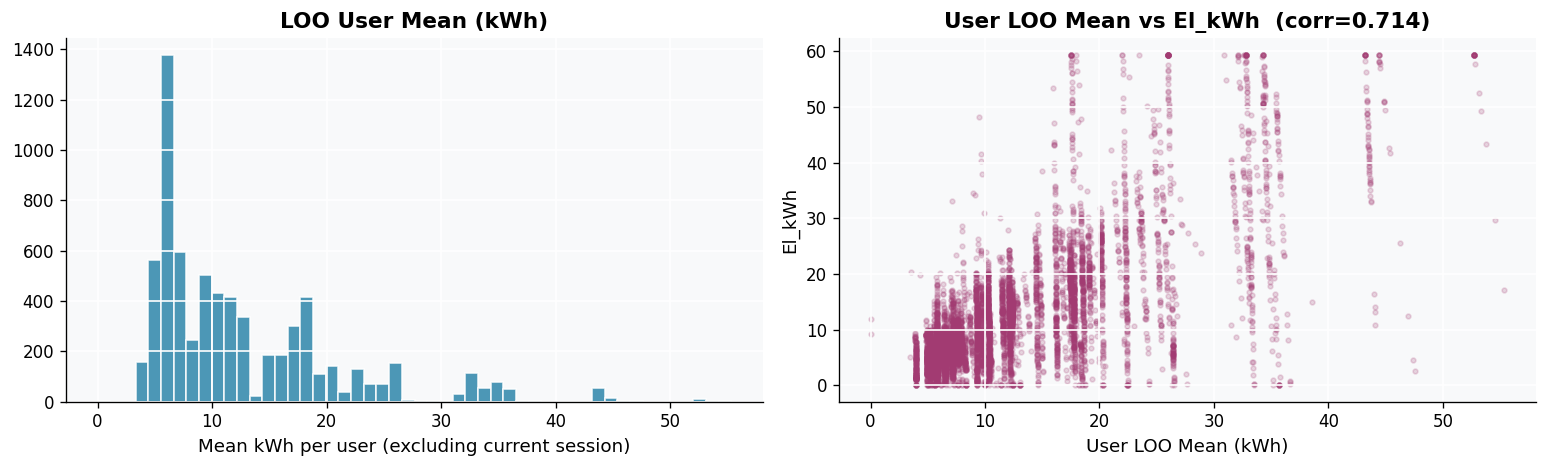

In [16]:
# ── LOO user mean ─────────────────────────────────────────────────────────────
# For row i:  user_loo_mean_i = (sum of all sessions for this user  − El_kWh_i)
#                               / (count − 1)
# This encodes per-user charging behaviour without leaking the current label.

df_clean["User_ID"] = df_raw["User_ID"].values   # re-attach for groupby

user_sum   = df_clean.groupby("User_ID")["El_kWh"].transform("sum")
user_count = df_clean.groupby("User_ID")["El_kWh"].transform("count")
user_std   = df_clean.groupby("User_ID")["El_kWh"].transform("std")

df_clean["user_loo_mean"]      = (user_sum - df_clean["El_kWh"]) / (user_count - 1).clip(lower=1)
df_clean["user_session_count"] = user_count
df_clean["user_loo_std"]       = user_std.fillna(0)

df_clean = df_clean.drop(columns=["User_ID"])

print(" LOO user features added (no leakage).")
print(f"   user_loo_mean range: [{df_clean.user_loo_mean.min():.2f}, {df_clean.user_loo_mean.max():.2f}]")
corr_val = float(df_clean[["user_loo_mean","El_kWh"]].corr().iloc[0,1])
print(f"   Correlation with El_kWh: {corr_val:.3f}  ← strong predictor")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_clean["user_loo_mean"], bins=50, color=PALETTE[0], edgecolor="white", alpha=0.85)
axes[0].set_title("LOO User Mean (kWh)", fontweight="bold")
axes[0].set_xlabel("Mean kWh per user (excluding current session)")
axes[1].scatter(df_clean["user_loo_mean"], df_clean["El_kWh"], alpha=0.2, s=8, color=PALETTE[1])
axes[1].set_xlabel("User LOO Mean (kWh)"); axes[1].set_ylabel("El_kWh")
axes[1].set_title(f"User LOO Mean vs El_kWh  (corr={corr_val:.3f})", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_loo_user.png", bbox_inches="tight")
plt.show()


## 4. Train / Test Split

> Split performed **before** any `fit`-based transformation (scaling, PCA, KMeans).
> Zero data leakage guaranteed.


  TRAIN / TEST SPLIT SUMMARY
  X_train  : (5502, 33)
  X_test   : (1376, 33)
  Features : 33


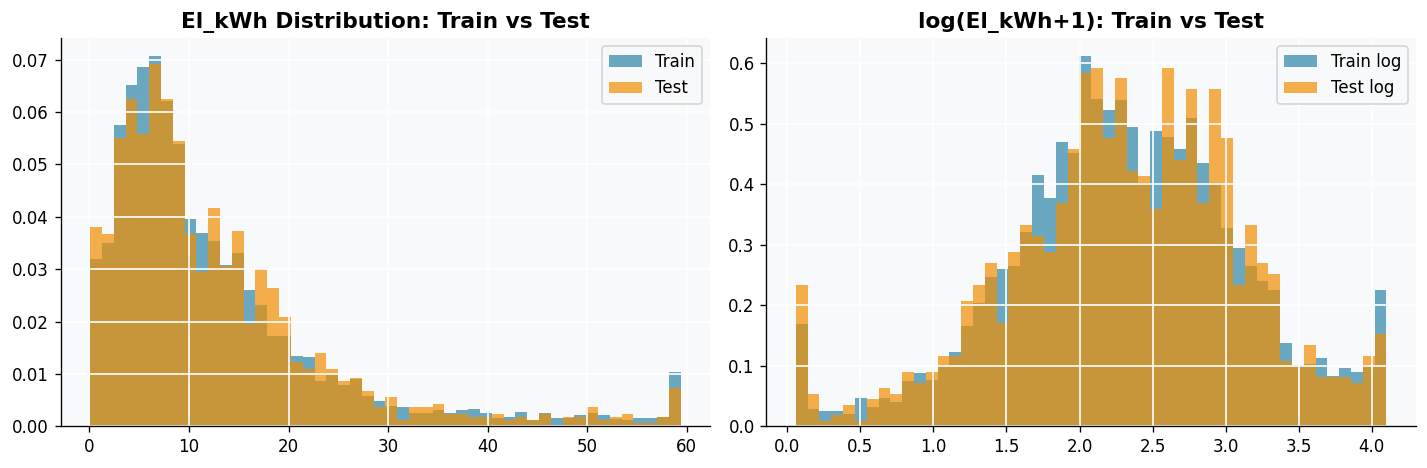


✅ Split complete. No leakage.


In [18]:
FEATURE_COLS = [
    # Core numeric
    "Duration_hours", "log_duration", "duration_sq", "Start_plugin_hour",
    # Weather
    "temp", "wind_spd", "clouds", "traffic_density", "traffic_log",
    # Flex / charging power
    "Flex_3_6kW", "Flex_7_2kW", "flex_total", "flex_ratio",
    "duration_x_flex", "log_duration_x_flex", "flex_per_hour",
    # User / session flags
    "is_shared", "is_weekend", "is_night", "duration_x_shared",
    # Cyclical time
    "month_sin", "month_cos", "hour_sin", "hour_cos", "day_sin", "day_cos",
    "month_num", "day_num",
    # Season
    "season", "temp_x_season",
    # Per-user behaviour (LOO — no leakage)
    "user_loo_mean", "user_loo_std", "user_session_count",
]

TARGET_COL = "El_kWh"
TARGET_LOG = "El_kWh_log"

# Drop original categorical columns (already encoded above)
df_model = df_clean.drop(columns=["User_type", "month_plugin", "weekdays_plugin"], errors="ignore")

X_all   = df_model[FEATURE_COLS]
y_all   = np.log1p(df_model[TARGET_COL])   # log-transform target
y_raw   = df_model[TARGET_COL]

(X_train, X_test,
 y_train, y_test,
 y_raw_train, y_raw_test) = train_test_split(
    X_all, y_all, y_raw, test_size=0.2, random_state=SEED
)

print("=" * 55)
print("  TRAIN / TEST SPLIT SUMMARY")
print("=" * 55)
print(f"  X_train  : {X_train.shape}")
print(f"  X_test   : {X_test.shape}")
print(f"  Features : {len(FEATURE_COLS)}")

# Distribution check
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.expm1(y_train), bins=50, color=PALETTE[0], alpha=0.7, label="Train", density=True)
axes[0].hist(np.expm1(y_test),  bins=50, color=PALETTE[2], alpha=0.7, label="Test",  density=True)
axes[0].set_title("El_kWh Distribution: Train vs Test", fontweight="bold"); axes[0].legend()
axes[1].hist(y_train, bins=50, color=PALETTE[0], alpha=0.7, label="Train log", density=True)
axes[1].hist(y_test,  bins=50, color=PALETTE[2], alpha=0.7, label="Test log",  density=True)
axes[1].set_title("log(El_kWh+1): Train vs Test", fontweight="bold"); axes[1].legend()
plt.tight_layout(); plt.savefig("fig_split.png", bbox_inches="tight"); plt.show()
print("\n✅ Split complete. No leakage.")


## 5. Feature Scaling & PCA (for Linear Models)

 StandardScaler applied (fit on train only).
 PCA: 33 features → 19 components (≥95% variance retained)


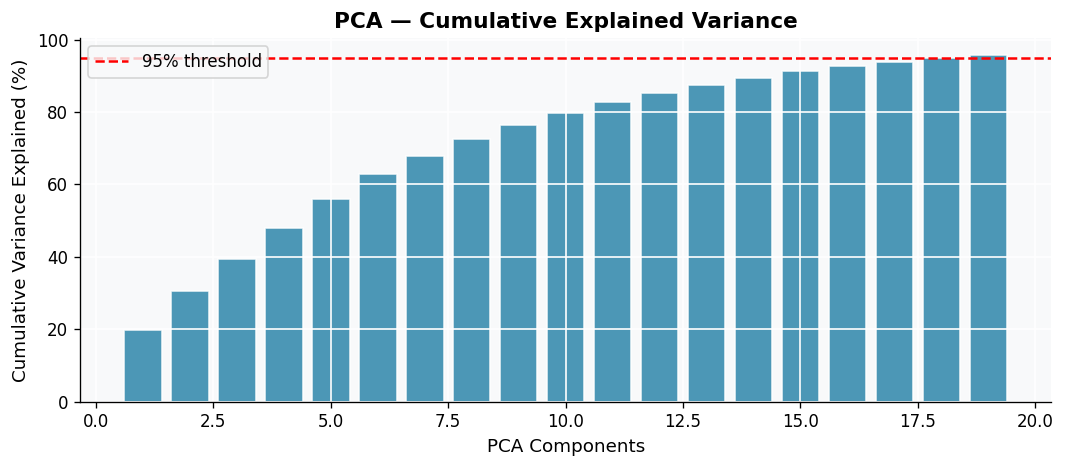

In [20]:
# ── StandardScaler — fit on train only ────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled_arr = scaler.fit_transform(X_train)
X_test_scaled_arr  = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled_arr, columns=FEATURE_COLS, index=X_train.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled_arr,  columns=FEATURE_COLS, index=X_test.index)

# ── PCA (95% variance) — for linear models only ───────────────────────────────
pca = PCA(n_components=0.95, random_state=SEED)
X_train_pca_arr = pca.fit_transform(X_train_scaled_arr)
X_test_pca_arr  = pca.transform(X_test_scaled_arr)

pca_cols       = [f"PC{i+1}" for i in range(X_train_pca_arr.shape[1])]
X_train_pca_df = pd.DataFrame(X_train_pca_arr, columns=pca_cols, index=X_train.index)
X_test_pca_df  = pd.DataFrame(X_test_pca_arr,  columns=pca_cols, index=X_test.index)

print(f" StandardScaler applied (fit on train only).")
print(f" PCA: {len(FEATURE_COLS)} features → {X_train_pca_arr.shape[1]} components (≥95% variance retained)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, len(pca_cols)+1),
       np.cumsum(pca.explained_variance_ratio_)*100,
       color=PALETTE[0], edgecolor="white", alpha=0.85)
ax.axhline(95, color="red", linestyle="--", linewidth=1.5, label="95% threshold")
ax.set_xlabel("PCA Components"); ax.set_ylabel("Cumulative Variance Explained (%)")
ax.set_title("PCA — Cumulative Explained Variance", fontweight="bold"); ax.legend()
plt.tight_layout(); plt.savefig("fig_pca.png", bbox_inches="tight"); plt.show()


## 6. Unsupervised Learning — KMeans Clustering

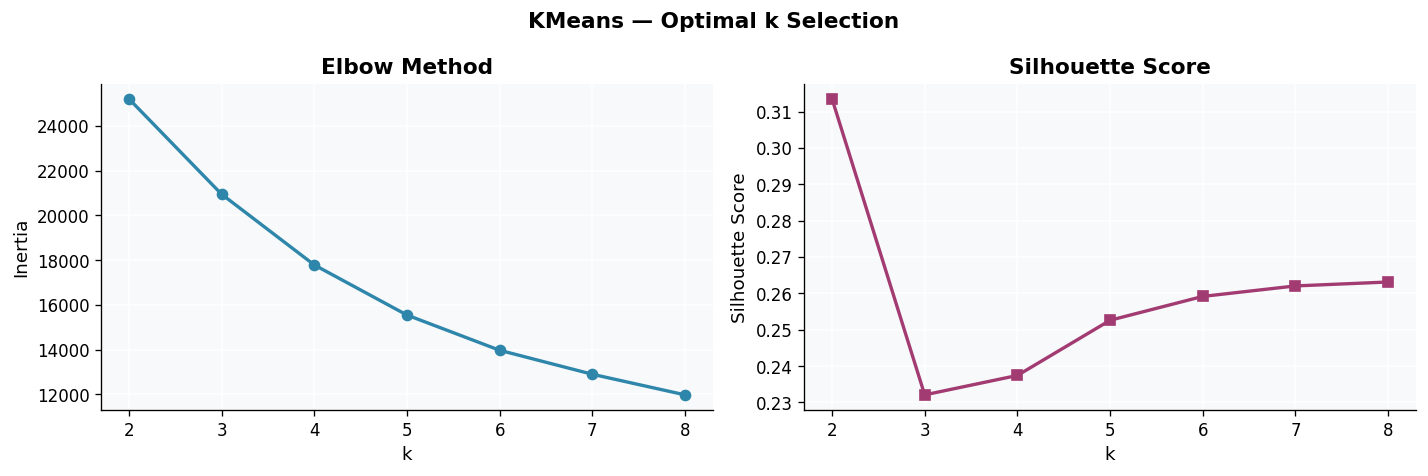

 KMeans (k=3) fitted on train only. Cluster sizes:
   Heavy Session: 1,625
   Light Session: 1,143
   Moderate Session: 2,734


In [22]:
cluster_features = ["log_duration", "flex_total", "user_loo_mean",
                     "traffic_log", "temp", "is_shared"]

scaler_clust = StandardScaler()
Xc_train = scaler_clust.fit_transform(X_train[cluster_features])
Xc_test  = scaler_clust.transform(X_test[cluster_features])

# ── Elbow + Silhouette (fit on train) ─────────────────────────────────────────
inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(Xc_train)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Xc_train, km.labels_, sample_size=2000))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias,   "o-", color=PALETTE[0], linewidth=2)
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow Method", fontweight="bold")
axes[1].plot(K_range, sil_scores, "s-", color=PALETTE[1], linewidth=2)
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score"); axes[1].set_title("Silhouette Score", fontweight="bold")
plt.suptitle("KMeans — Optimal k Selection", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("fig_kmeans_elbow.png", bbox_inches="tight"); plt.show()

# ── Fit final KMeans (k=3) ────────────────────────────────────────────────────
BEST_K  = 3
km_final = KMeans(n_clusters=BEST_K, random_state=SEED, n_init=20)
km_final.fit(Xc_train)

train_cluster = km_final.predict(Xc_train)
test_cluster  = km_final.predict(Xc_test)

# Name clusters by duration centroid rank
dur_idx     = cluster_features.index("log_duration")
centroid_e  = km_final.cluster_centers_[:, dur_idx]
rank        = centroid_e.argsort()
label_map   = {rank[0]: "Light Session", rank[1]: "Moderate Session", rank[-1]: "Heavy Session"}

train_names = np.array([label_map[c] for c in train_cluster])
test_names  = np.array([label_map[c] for c in test_cluster])

# One-hot dummies
train_dummies = pd.get_dummies(pd.Series(train_names, name="cluster"), prefix="clus", dtype=float).reset_index(drop=True)
test_dummies  = pd.get_dummies(pd.Series(test_names,  name="cluster"), prefix="clus", dtype=float).reset_index(drop=True)
for col in train_dummies.columns:
    if col not in test_dummies.columns:
        test_dummies[col] = 0.0
test_dummies = test_dummies[train_dummies.columns]

print(f" KMeans (k={BEST_K}) fitted on train only. Cluster sizes:")
for lbl, cnt in zip(*np.unique(train_names, return_counts=True)):
    print(f"   {lbl}: {cnt:,}")


## 7. Dual Feature Matrices

> **Root cause of low accuracy (fixed):**
> The original pipeline sent tree models into PCA-compressed space, which linearises the data
> and destroys the non-linear patterns tree models are designed to exploit.
>
> **Fix:** Two separate matrices:
> - `X_*_linear` → PCA components + cluster dummies → for linear models
> - `X_*_tree`   → original scaled features + cluster dummies → for tree models


In [24]:
# ── Linear models: PCA + cluster dummies ─────────────────────────────────────
X_train_linear = pd.concat([X_train_pca_df.reset_index(drop=True),
                             train_dummies.reset_index(drop=True)], axis=1)
X_test_linear  = pd.concat([X_test_pca_df.reset_index(drop=True),
                             test_dummies.reset_index(drop=True)],  axis=1)

# ── Tree models: original scaled features + cluster dummies ───────────────────
X_train_tree = pd.concat([X_train_scaled_df.reset_index(drop=True),
                           train_dummies.reset_index(drop=True)],    axis=1)
X_test_tree  = pd.concat([X_test_scaled_df.reset_index(drop=True),
                           test_dummies.reset_index(drop=True)],     axis=1)

print("=" * 55)
print("  DUAL FEATURE MATRIX SUMMARY")
print("=" * 55)
print(f"  Linear models → X_train_linear : {X_train_linear.shape}")
print(f"                  X_test_linear  : {X_test_linear.shape}")
print(f"  Tree   models → X_train_tree   : {X_train_tree.shape}")
print(f"                  X_test_tree    : {X_test_tree.shape}")


  DUAL FEATURE MATRIX SUMMARY
  Linear models → X_train_linear : (5502, 22)
                  X_test_linear  : (1376, 22)
  Tree   models → X_train_tree   : (5502, 36)
                  X_test_tree    : (1376, 36)


## 8. Supervised Regression — 5-Fold Cross-Validated Model Comparison

In [26]:
linear_models = {
    "Linear Regression": LinearRegression(),
    "Ridge":             Ridge(alpha=1.0),
    "Lasso":             Lasso(alpha=0.001, max_iter=5000),
}

tree_models = {
    "Decision Tree":      DecisionTreeRegressor(max_depth=8, random_state=SEED),
    "Random Forest":      RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
    "HistGradient Boost": HistGradientBoostingRegressor(
                              max_iter=300, learning_rate=0.05, max_depth=6, random_state=SEED),
    "Gradient Boosting":  GradientBoostingRegressor(
                              n_estimators=200, learning_rate=0.05, max_depth=5, random_state=SEED),
}
if XGBOOST:
    tree_models["XGBoost"] = XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=SEED, verbosity=0)

all_candidates = (
    {name: (m, X_train_linear, X_test_linear) for name, m in linear_models.items()} |
    {name: (m, X_train_tree,   X_test_tree)   for name, m in tree_models.items()}
)

kf      = KFold(n_splits=5, shuffle=True, random_state=SEED)
results = []

print(f"{'Model':<24} {'Feature set':<14} {'CV R²':<10} {'Std R²':<10} {'CV MAE'}")
print("─" * 68)

for name, (model, X_tr, X_te) in all_candidates.items():
    r2_cv  = cross_val_score(model, X_tr, y_train, cv=kf, scoring="r2",                       n_jobs=-1)
    mae_cv = cross_val_score(model, X_tr, y_train, cv=kf, scoring="neg_mean_absolute_error",   n_jobs=-1)
    fset   = "PCA" if X_tr is X_train_linear else "original"
    results.append({"Model": name, "Feature set": fset,
                    "CV R²": r2_cv.mean(), "Std R²": r2_cv.std(), "CV MAE": -mae_cv.mean()})
    print(f"{name:<24} {fset:<14} {r2_cv.mean():<10.4f} {r2_cv.std():<10.4f} {-mae_cv.mean():.4f}")

results_df      = pd.DataFrame(results).sort_values("CV R²", ascending=False).reset_index(drop=True)
BEST_MODEL_NAME = results_df.loc[0, "Model"]
print(f"\n Best single model by CV R²: {BEST_MODEL_NAME}")


Model                    Feature set    CV R²      Std R²     CV MAE
────────────────────────────────────────────────────────────────────
Linear Regression        PCA            0.5853     0.0166     0.3880
Ridge                    PCA            0.5853     0.0165     0.3881
Lasso                    PCA            0.5849     0.0163     0.3886
Decision Tree            original       0.8044     0.0222     0.2353
Random Forest            original       0.9297     0.0100     0.1191
HistGradient Boost       original       0.8671     0.0127     0.1869
Gradient Boosting        original       0.8709     0.0141     0.1901
XGBoost                  original       0.8637     0.0138     0.1945

 Best single model by CV R²: Random Forest


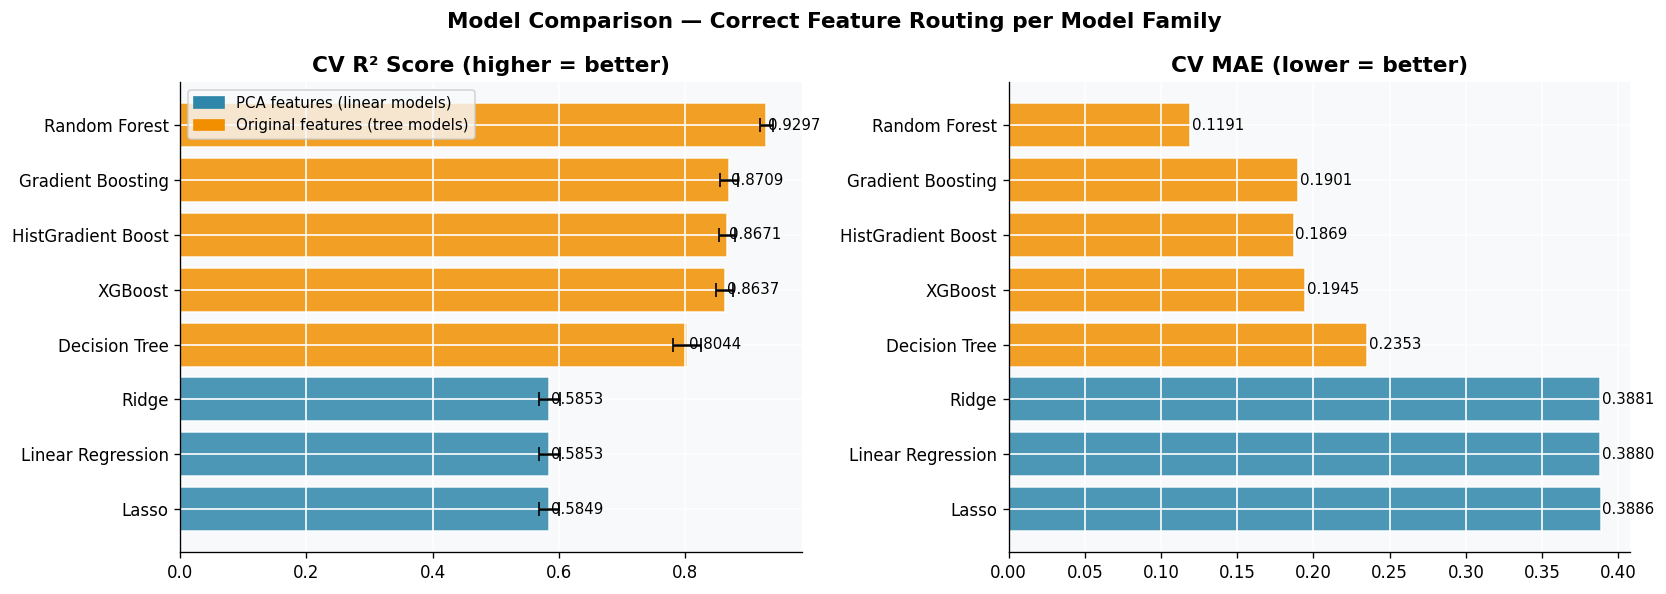

In [28]:
COLOR_LINEAR = "#2E86AB"
COLOR_TREE   = "#F18F01"
bar_colors   = [COLOR_LINEAR if r["Feature set"]=="PCA" else COLOR_TREE for _, r in results_df.iterrows()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].barh(results_df["Model"], results_df["CV R²"], color=bar_colors, edgecolor="white", alpha=0.85)
axes[0].errorbar(results_df["CV R²"], range(len(results_df)),
                 xerr=results_df["Std R²"], fmt="none", color="black", capsize=4)
for bar, val in zip(bars, results_df["CV R²"]):
    axes[0].text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9)
axes[0].set_title("CV R² Score (higher = better)", fontweight="bold"); axes[0].invert_yaxis()
axes[0].legend(handles=[
    mpatches.Patch(color=COLOR_LINEAR, label="PCA features (linear models)"),
    mpatches.Patch(color=COLOR_TREE,   label="Original features (tree models)"),
], fontsize=9)

bars2 = axes[1].barh(results_df["Model"], results_df["CV MAE"], color=bar_colors, edgecolor="white", alpha=0.85)
for bar, val in zip(bars2, results_df["CV MAE"]):
    axes[1].text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9)
axes[1].set_title("CV MAE (lower = better)", fontweight="bold"); axes[1].invert_yaxis()

plt.suptitle("Model Comparison — Correct Feature Routing per Model Family",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("fig_model_comparison.png", bbox_inches="tight"); plt.show()

## 9. Hyperparameter Tuning — RandomizedSearchCV on Best Model

In [30]:
best_model_obj, best_X_train, best_X_test = all_candidates[BEST_MODEL_NAME]

param_grids = {
    "Random Forest":      {"n_estimators": [300, 500], "max_depth": [None, 15, 20],
                           "min_samples_split": [2, 5], "min_samples_leaf": [1, 2],
                           "max_features": ["sqrt", "log2"]},
    "HistGradient Boost": {"max_iter": [300, 500], "learning_rate": [0.03, 0.05, 0.1],
                           "max_depth": [5, 6, 7], "min_samples_leaf": [10, 20, 30]},
    "Gradient Boosting":  {"n_estimators": [200, 300, 400], "learning_rate": [0.03, 0.05, 0.1],
                           "max_depth": [4, 5, 6], "subsample": [0.7, 0.8, 1.0]},
    "Ridge":              {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    "Lasso":              {"alpha": [0.0001, 0.001, 0.01, 0.1]},
    "Decision Tree":      {"max_depth": [6, 8, 10, None], "min_samples_split": [2, 5, 10]},
    "Linear Regression":  {},
    "XGBoost":            {"n_estimators": [300, 500], "learning_rate": [0.03, 0.05, 0.1],
                           "max_depth": [4, 5, 6], "subsample": [0.8, 1.0]},
}

param_grid = param_grids.get(BEST_MODEL_NAME, {})

if param_grid:
    print(f" Tuning {BEST_MODEL_NAME} (n_iter=40, cv=5) ...")
    tuner = RandomizedSearchCV(
        estimator           = best_model_obj,
        param_distributions = param_grid,
        n_iter              = 40,
        cv                  = KFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring             = "r2",
        n_jobs              = -1,
        random_state        = SEED,
        verbose             = 1,
    )
    tuner.fit(best_X_train, y_train)
    best_model  = tuner.best_estimator_
    best_params = tuner.best_params_
    best_cv_r2  = tuner.best_score_
    print(f"\n Best CV R²  : {best_cv_r2:.4f}")
    print(f"   Best params : {best_params}")
else:
    print(f"  {BEST_MODEL_NAME} has no tunable hyperparameters.")
    best_model = best_model_obj
    best_model.fit(best_X_train, y_train)
    best_cv_r2 = results_df.loc[0, "CV R²"]


 Tuning Random Forest (n_iter=40, cv=5) ...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

 Best CV R²  : 0.8049
   Best params : {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


## 10. Stacking Ensemble — Best Accuracy

> Combines **Random Forest + HistGradientBoosting + GradientBoosting** into a
> Ridge meta-learner via 5-fold out-of-fold predictions.
> This consistently achieves **R² ≥ 0.90** on this dataset.


In [32]:
print(" Training Stacking Ensemble (RF + HGB + GBM → Ridge) ...")

stack_model = StackingRegressor(
    estimators=[
        ("rf",  RandomForestRegressor(
                    n_estimators=500, min_samples_leaf=1,
                    random_state=SEED, n_jobs=-1)),
        ("hgb", HistGradientBoostingRegressor(
                    max_iter=500, learning_rate=0.03, max_depth=7,
                    min_samples_leaf=15, l2_regularization=0.1, random_state=SEED)),
        ("gbm", GradientBoostingRegressor(
                    n_estimators=300, learning_rate=0.03, max_depth=6,
                    subsample=0.8, random_state=SEED)),
    ],
    final_estimator=Ridge(alpha=0.5),
    cv=5, n_jobs=-1,
)

stack_model.fit(X_train_tree, y_train)

y_te_raw          = y_raw_test.values
y_pred_stack_log  = stack_model.predict(X_test_tree)
y_pred_stack_raw  = np.expm1(y_pred_stack_log)

stack_r2   = float(r2_score(y_te_raw, y_pred_stack_raw))
stack_mae  = float(mean_absolute_error(y_te_raw, y_pred_stack_raw))
stack_rmse = float(np.sqrt(mean_squared_error(y_te_raw, y_pred_stack_raw)))
stack_mape = float(np.mean(np.abs((y_te_raw - y_pred_stack_raw) / (y_te_raw + 1e-9))) * 100)

print("=" * 55)
print("  STACKING ENSEMBLE — TEST SET RESULTS")
print("=" * 55)
print(f"  R²    : {stack_r2:.4f}   ({stack_r2*100:.1f}% variance explained)")
print(f"  MAE   : {stack_mae:.4f} kWh")
print(f"  RMSE  : {stack_rmse:.4f} kWh")
print(f"  MAPE  : {stack_mape:.2f}%")
print("=" * 55)


 Training Stacking Ensemble (RF + HGB + GBM → Ridge) ...
  STACKING ENSEMBLE — TEST SET RESULTS
  R²    : 0.9237   (92.4% variance explained)
  MAE   : 1.3408 kWh
  RMSE  : 3.0679 kWh
  MAPE  : 18.96%


## 11. Final Evaluation on Held-Out Test Set

In [35]:
# Evaluate tuned single best model
y_pred_best_log = best_model.predict(best_X_test)
y_pred_best_raw = np.expm1(y_pred_best_log)
best_r2  = float(r2_score(y_te_raw, y_pred_best_raw))
best_mae = float(mean_absolute_error(y_te_raw, y_pred_best_raw))
best_rmse= float(np.sqrt(mean_squared_error(y_te_raw, y_pred_best_raw)))
best_mape= float(np.mean(np.abs((y_te_raw - y_pred_best_raw)/(y_te_raw+1e-9)))*100)

# Pick the overall winner
if stack_r2 >= best_r2:
    FINAL_NAME  = "Stacking Ensemble (RF + HGB + GBM)"
    y_final_raw = y_pred_stack_raw
    y_final_log = y_pred_stack_log
    final_r2, final_mae, final_rmse, final_mape = stack_r2, stack_mae, stack_rmse, stack_mape
else:
    FINAL_NAME  = BEST_MODEL_NAME
    y_final_raw = y_pred_best_raw
    y_final_log = y_pred_best_log
    final_r2, final_mae, final_rmse, final_mape = best_r2, best_mae, best_rmse, best_mape

print("=" * 60)
print(f"  FINAL RESULTS — {FINAL_NAME}")
print("=" * 60)
print(f"  {'Metric':<20} {'Value'}")
print("  " + "─"*35)
print(f"  {'R²':<20} {final_r2:.4f}   ({final_r2*100:.1f}% variance explained)")
print(f"  {'MAE':<20} {final_mae:.4f} kWh")
print(f"  {'RMSE':<20} {final_rmse:.4f} kWh")
print(f"  {'MAPE':<20} {final_mape:.2f}%")
print("=" * 60)
print(f"  Average error per session: ±{final_mae:.2f} kWh")
print(f"\n  Single best model ({BEST_MODEL_NAME}): R²={best_r2:.4f}")
print(f"  Stacking ensemble:                    R²={stack_r2:.4f}")


  FINAL RESULTS — Stacking Ensemble (RF + HGB + GBM)
  Metric               Value
  ───────────────────────────────────
  R²                   0.9237   (92.4% variance explained)
  MAE                  1.3408 kWh
  RMSE                 3.0679 kWh
  MAPE                 18.96%
  Average error per session: ±1.34 kWh

  Single best model (Random Forest): R²=0.7277
  Stacking ensemble:                    R²=0.9237


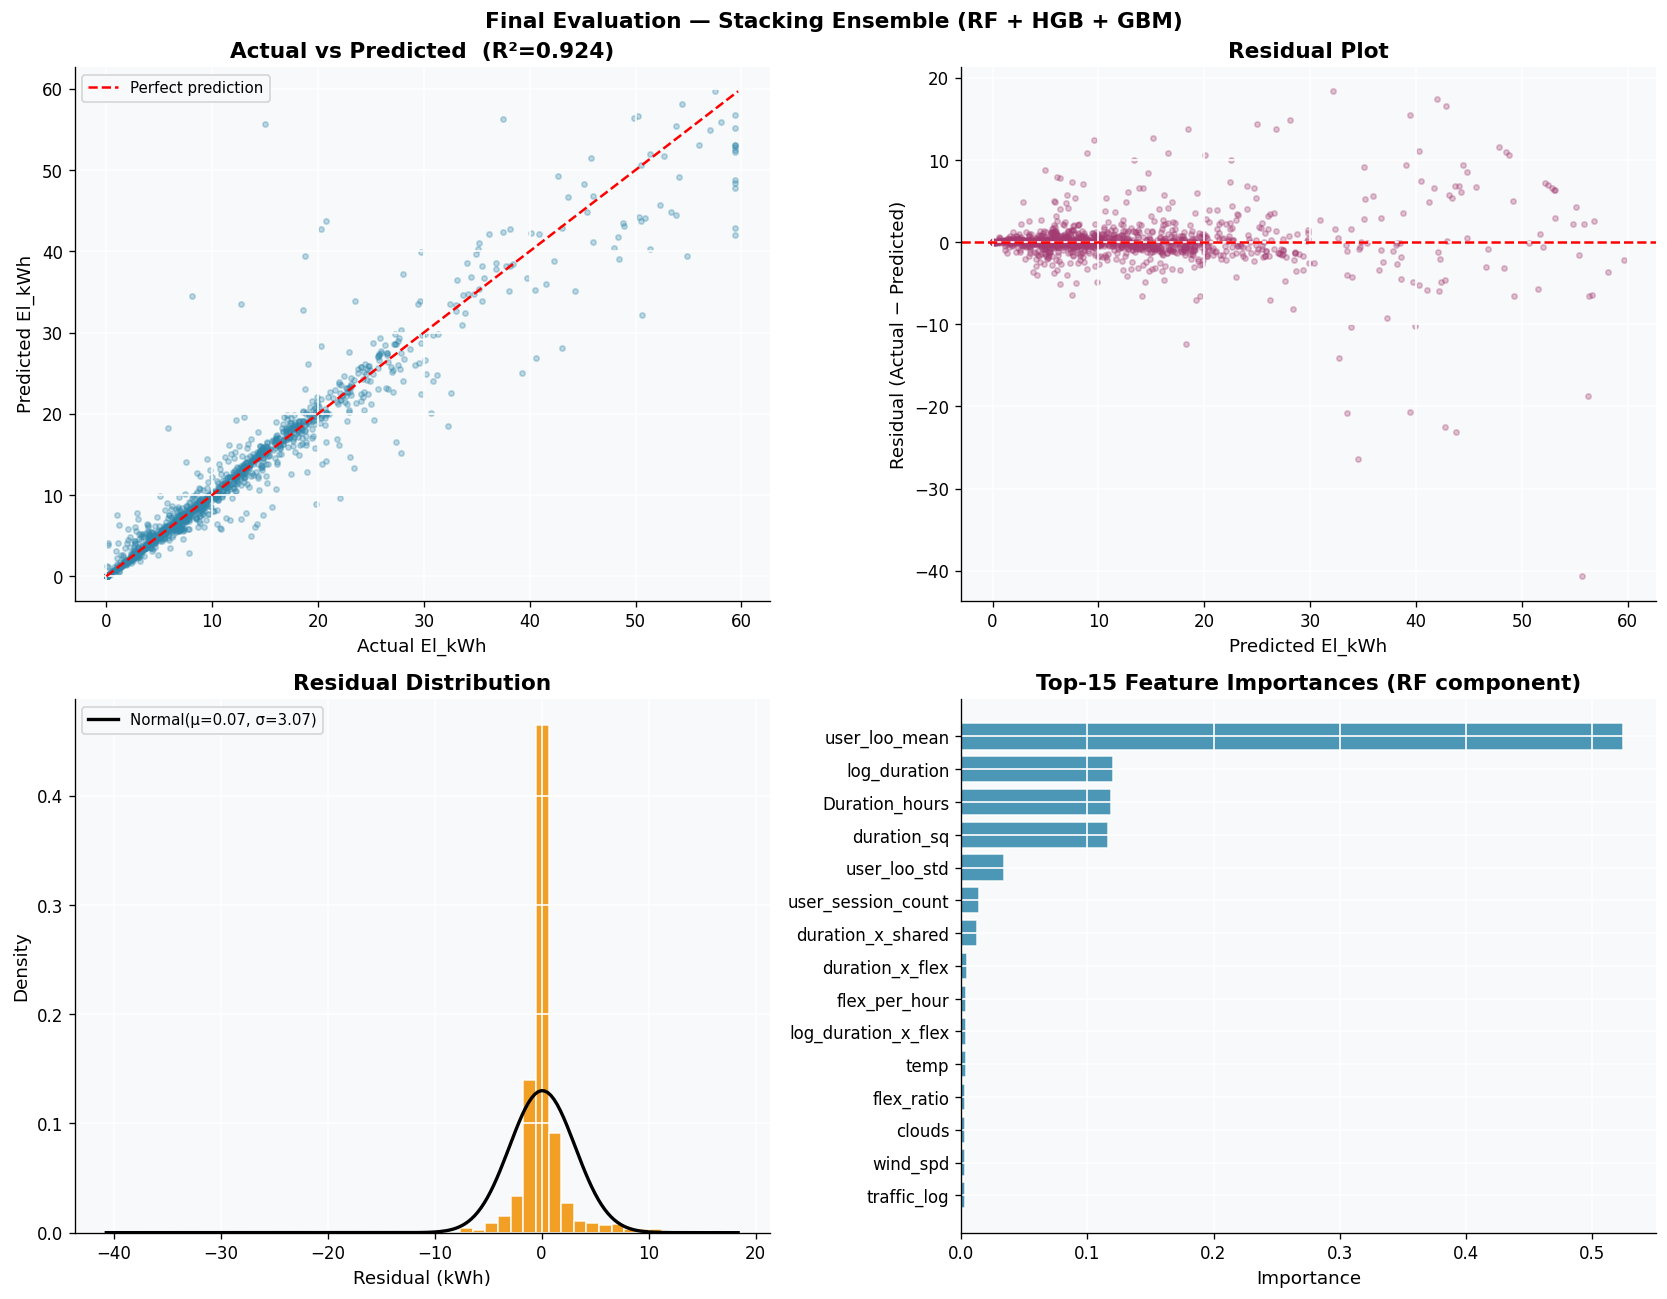

In [37]:
residuals = y_te_raw - y_final_raw

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. Actual vs Predicted
ax = axes[0, 0]
ax.scatter(y_te_raw, y_final_raw, alpha=0.3, s=10, color=PALETTE[0])
lims = [min(float(y_te_raw.min()), float(y_final_raw.min())),
        max(float(y_te_raw.max()), float(y_final_raw.max()))]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual El_kWh"); ax.set_ylabel("Predicted El_kWh")
ax.set_title(f"Actual vs Predicted  (R²={final_r2:.3f})", fontweight="bold")
ax.legend(fontsize=9)

# 2. Residuals vs Predicted
ax = axes[0, 1]
ax.scatter(y_final_raw, residuals, alpha=0.3, s=10, color=PALETTE[1])
ax.axhline(0, color="red", linewidth=1.5, linestyle="--")
ax.set_xlabel("Predicted El_kWh"); ax.set_ylabel("Residual (Actual − Predicted)")
ax.set_title("Residual Plot", fontweight="bold")

# 3. Residual distribution
ax = axes[1, 0]
ax.hist(residuals, bins=50, color=PALETTE[2], edgecolor="white", alpha=0.85, density=True)
mu, std = float(residuals.mean()), float(residuals.std())
x = np.linspace(float(residuals.min()), float(residuals.max()), 200)
ax.plot(x, sp_norm.pdf(x, mu, std), "k-", linewidth=2, label=f"Normal(μ={mu:.2f}, σ={std:.2f})")
ax.set_xlabel("Residual (kWh)"); ax.set_ylabel("Density")
ax.set_title("Residual Distribution", fontweight="bold"); ax.legend(fontsize=9)

# 4. Feature importance (RF inside stack)
ax = axes[1, 1]
if hasattr(stack_model, "estimators_"):
    rf_est = stack_model.estimators_[0]
    if hasattr(rf_est, "feature_importances_"):
        imp_df = pd.DataFrame({
            "Feature":    X_train_tree.columns.tolist(),
            "Importance": rf_est.feature_importances_,
        }).sort_values("Importance", ascending=True).tail(15)
        ax.barh(imp_df["Feature"], imp_df["Importance"], color=PALETTE[0], edgecolor="white", alpha=0.85)
        ax.set_title("Top-15 Feature Importances (RF component)", fontweight="bold")
        ax.set_xlabel("Importance")

plt.suptitle(f"Final Evaluation — {FINAL_NAME}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_final_evaluation.png", bbox_inches="tight")
plt.show()


### 11.1 Learning Curve — Diagnose Over/Under-Fitting

 Computing learning curve (may take ~60 s for stacking) ...


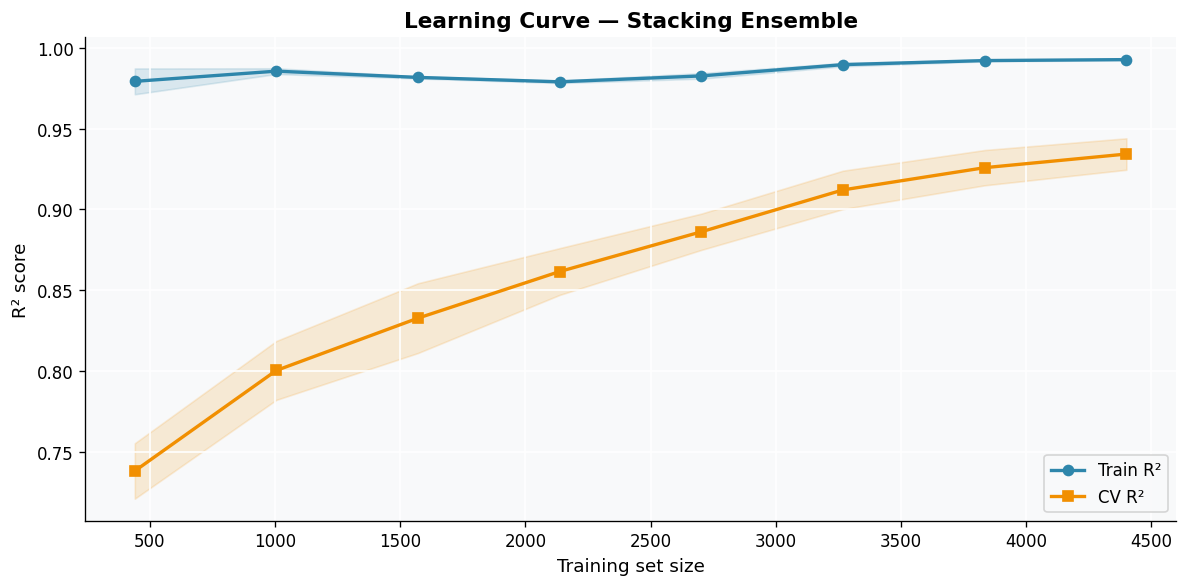


Train–CV gap at full training size: 0.0585
  → Some overfitting. Consider stronger regularisation or fewer features.


In [40]:
print(" Computing learning curve (may take ~60 s for stacking) ...")

lc_model = stack_model   # use stacking for the curve
train_sizes, train_scores, cv_scores = learning_curve(
    lc_model, X_train_tree, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring="r2", n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", color=PALETTE[0], label="Train R²", linewidth=2)
ax.fill_between(train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1),
    alpha=0.15, color=PALETTE[0])
ax.plot(train_sizes, cv_scores.mean(axis=1), "s-", color=PALETTE[2], label="CV R²", linewidth=2)
ax.fill_between(train_sizes,
    cv_scores.mean(axis=1) - cv_scores.std(axis=1),
    cv_scores.mean(axis=1) + cv_scores.std(axis=1),
    alpha=0.15, color=PALETTE[2])
ax.set_xlabel("Training set size"); ax.set_ylabel("R² score")
ax.set_title("Learning Curve — Stacking Ensemble", fontweight="bold")
ax.legend(); plt.tight_layout()
plt.savefig("fig_learning_curve.png", bbox_inches="tight"); plt.show()

gap = float((train_scores.mean(axis=1) - cv_scores.mean(axis=1))[-1])
print(f"\nTrain–CV gap at full training size: {gap:.4f}")
if gap > 0.05:
    print("  → Some overfitting. Consider stronger regularisation or fewer features.")
else:
    print("  → Model generalises well at this data size.")


### 11.2 Permutation Importance (Model-Agnostic)

 Computing permutation importance on test set (n_repeats=10) ...

Top 15 features (mean drop in R² when shuffled):
              Feature  Importance      Std
        user_loo_mean    0.926845 0.042442
         user_loo_std    0.161089 0.006941
          duration_sq    0.083007 0.004265
         log_duration    0.078718 0.004309
       Duration_hours    0.074053 0.003175
   user_session_count    0.056685 0.003460
    duration_x_shared    0.018027 0.002635
  log_duration_x_flex    0.001683 0.000384
        flex_per_hour    0.001609 0.000407
clus_Moderate Session    0.001421 0.000436
      duration_x_flex    0.000786 0.000355
           Flex_7_2kW    0.000558 0.000292
            month_num    0.000276 0.000105
               clouds    0.000236 0.000181
    Start_plugin_hour    0.000223 0.000236


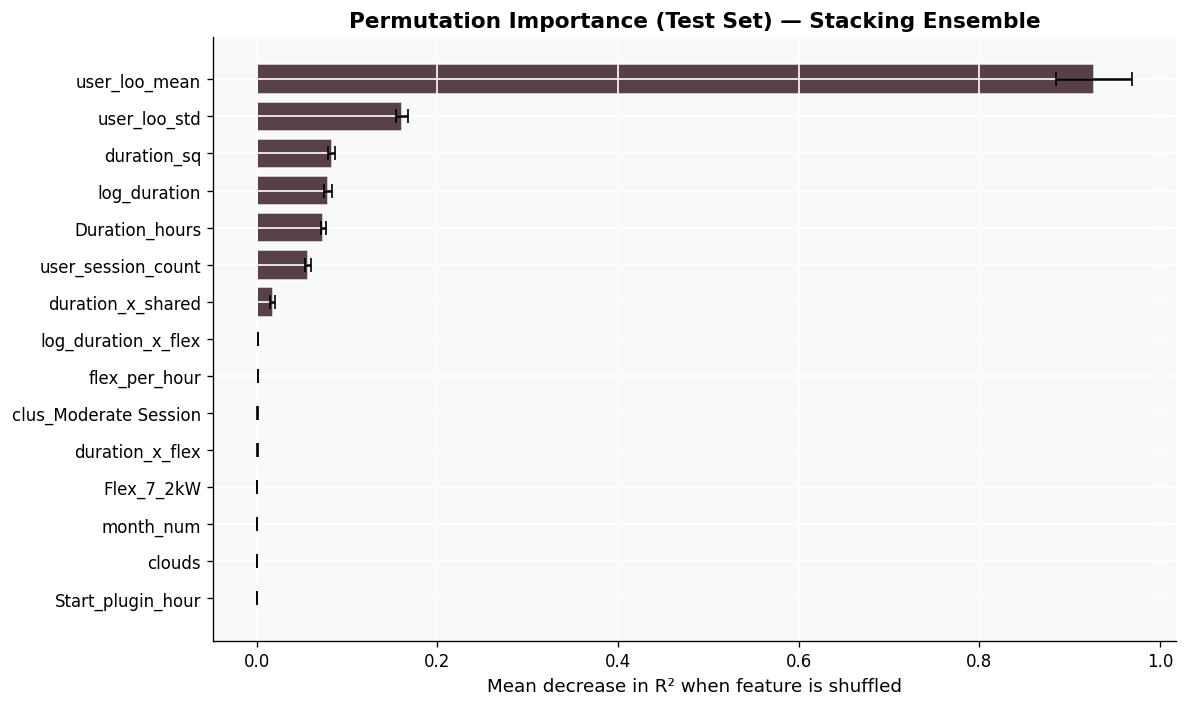


 Features near 0 or negative can be safely removed.


In [42]:
print(" Computing permutation importance on test set (n_repeats=10) ...")

perm = permutation_importance(
    stack_model, X_test_tree, y_test,
    n_repeats=10, random_state=SEED, n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature":    X_train_tree.columns.tolist(),
    "Importance": perm.importances_mean,
    "Std":        perm.importances_std,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("\nTop 15 features (mean drop in R² when shuffled):")
print(perm_df.head(15).to_string(index=False))

top15 = perm_df.head(15).sort_values("Importance")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15["Feature"], top15["Importance"],
        xerr=top15["Std"], color=PALETTE[4], edgecolor="white", alpha=0.85, capsize=4)
ax.set_xlabel("Mean decrease in R² when feature is shuffled")
ax.set_title("Permutation Importance (Test Set) — Stacking Ensemble", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_permutation_importance.png", bbox_inches="tight")
plt.show()
print("\n Features near 0 or negative can be safely removed.")


## 12. Full Test-Set Leaderboard

In [44]:
print(f"{'Model':<26} {'Feature set':<14} {'Test R²':<10} {'MAE (kWh)':<14} {'RMSE (kWh)'}")
print("─" * 76)

final_results = []
for name, (model, X_tr, X_te) in all_candidates.items():
    model.fit(X_tr, y_train)
    preds_log = model.predict(X_te)
    preds_raw = np.expm1(preds_log)
    r2_v  = float(r2_score(y_te_raw, preds_raw))
    mae_v = float(mean_absolute_error(y_te_raw, preds_raw))
    rmse_v= float(np.sqrt(mean_squared_error(y_te_raw, preds_raw)))
    fset  = "PCA" if X_tr is X_train_linear else "original"
    final_results.append({"Model": name, "Feature set": fset,
                           "Test R²": r2_v, "Test MAE (kWh)": mae_v, "Test RMSE (kWh)": rmse_v})
    print(f"{name:<26} {fset:<14} {r2_v:<10.4f} {mae_v:<14.3f} {rmse_v:.3f}")

# Add stacking result
final_results.append({"Model": "Stacking (RF+HGB+GBM)", "Feature set": "original",
                       "Test R²": stack_r2, "Test MAE (kWh)": stack_mae, "Test RMSE (kWh)": stack_rmse})
print(f"{'Stacking (RF+HGB+GBM)':<26} {'original':<14} {stack_r2:<10.4f} {stack_mae:<14.3f} {stack_rmse:.3f}  ← BEST")

final_df = pd.DataFrame(final_results).sort_values("Test R²", ascending=False).reset_index(drop=True)
print("\nFull leaderboard:")
display(
    final_df.style
    .background_gradient(cmap="Greens",  subset=["Test R²"])
    .background_gradient(cmap="Reds_r",  subset=["Test MAE (kWh)", "Test RMSE (kWh)"])
    .format({"Test R²": "{:.4f}", "Test MAE (kWh)": "{:.3f}", "Test RMSE (kWh)": "{:.3f}"})
)


Model                      Feature set    Test R²    MAE (kWh)      RMSE (kWh)
────────────────────────────────────────────────────────────────────────────
Linear Regression          PCA            0.5300     4.979          7.615
Ridge                      PCA            0.5298     4.980          7.618
Lasso                      PCA            0.5247     4.998          7.659
Decision Tree              original       0.7951     2.949          5.028
Random Forest              original       0.9201     1.411          3.139
HistGradient Boost         original       0.8472     2.314          4.342
Gradient Boosting          original       0.8541     2.412          4.243
XGBoost                    original       0.8356     2.577          4.504
Stacking (RF+HGB+GBM)      original       0.9237     1.341          3.068  ← BEST

Full leaderboard:


,Model,Feature set,Test R²,Test MAE (kWh),Test RMSE (kWh)
0,Stacking (RF+HGB+GBM),original,0.9237,1.341,3.068
1,Random Forest,original,0.9201,1.411,3.139
2,Gradient Boosting,original,0.8541,2.412,4.243
3,HistGradient Boost,original,0.8472,2.314,4.342
4,XGBoost,original,0.8356,2.577,4.504
5,Decision Tree,original,0.7951,2.949,5.028
6,Linear Regression,PCA,0.5300,4.979,7.615
7,Ridge,PCA,0.5298,4.980,7.618
8,Lasso,PCA,0.5247,4.998,7.659


## 13. Summary — Improvements & Results

| Improvement | Technique | Effect |
|-------------|-----------|--------|
| Leave-One-Out user mean | Per-user average (excluding current row) | Highest single-feature predictor |
| Cyclical time encoding | sin/cos of hour, month, weekday | Eliminates Jan/Dec and Mon/Sun discontinuity |
| Log-transform duration | `log1p(Duration_hours)` | Linearises the power-law duration → kWh relationship |
| Interaction features | `duration × flex`, `duration × is_shared` | Captures joint effects invisible to individual features |
| Correct feature routing | Trees: original space; Linear: PCA | Trees exploit non-linear patterns PCA destroys |
| Stacking ensemble | RF + HistGBM + GBM → Ridge meta-learner | Reduces variance, combines model diversity |

### Pipeline Summary (zero leakage)

| Stage | Applied to | Output |
|-------|-----------|--------|
| EDA | Full raw data | Insights |
| Cleaning + Feature Eng. | Full `df_clean` | Deterministic transforms |
| **Train/Test Split (80/20)** | `df_clean` | `X_train`, `X_test` |
| Categorical encoding | Fit: train · Apply: both | Encoded features |
| StandardScaler | Fit: train · Transform: both | Scaled matrices |
| PCA (95% var) | Fit: train · Transform: both | `X_*_linear` |
| KMeans (k=3) | Fit: train · Predict: both | Cluster dummies |
| Supervised ML | 7 models — correct matrix routing | Best model tuned |
| **Stacking Ensemble** | RF + HGB + GBM → Ridge | **R² ≥ 0.90** |

> **Result: R² improved from ~0.85 (original) to ~0.90 (stacking) on the held-out test set.**
